# 06 · Impacto económico, sin inventar moneda

## La restricción que define todo este notebook

En FreshRetailNet-50K `sale_amount` y `hours_sale` están multiplicados por un **coeficiente no
divulgado**. Consecuencia directa:

- Las métricas de exactitud —MASE, WAPE, pinball, cobertura— son válidas tal cual.
- **El ahorro monetario no se puede derivar del dataset.** Presentar guaraníes calculados sobre
  datos normalizados sería un número sin origen.

Así que el ROI se reporta **en porcentaje**. Eso no es timidez: es la única cifra que los datos
soportan. La traducción a moneda existe como capa aparte, paramétrica y con los supuestos a la
vista, en `docs/roi.md`.

## Y una segunda decisión, menos obvia

El simulador no compara dos políticas sino **cuatro**, porque un «ahorro del 12 %» suelto no se
puede interpretar. Hacen falta las cotas.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from blindside import config as cfg
from blindside.data import loaders
from blindside.data import schema as S
from blindside.decision import newsvendor as nv
from blindside.decision import policy as pol
from blindside.evaluate import contracts as C
from blindside.models.base import quantile_col

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (9, 3.2), "axes.grid": True, "grid.alpha": 0.25})

print("Las cuatro políticas que compara el simulador:")
print(f"  actual   ({pol.CURRENT_POLICY}): pide el pronóstico puntual, sin margen. Es la planilla.")
print(f"  modelo   ({pol.MODEL_POLICY}): pide el cuantil q*.")
print(f"  estática ({pol.STATIC_POLICY}): el mejor stock de seguridad fijo por serie.")
print(f"  perfecta ({pol.PERFECT_POLICY}): repone exactamente la demanda. Costo cero.")

Las cuatro políticas que compara el simulador:
  actual   (actual_promedio_movil): pide el pronóstico puntual, sin margen. Es la planilla.
  modelo   (modelo_qstar): pide el cuantil q*.
  estática (estatica_qstar_por_serie): el mejor stock de seguridad fijo por serie.
  perfecta (perfecta_sin_error): repone exactamente la demanda. Costo cero.


### Por qué hacen falta las cuatro

**La política estática** usa conocimiento perfecto de la distribución de cada producto pero
**ninguna información del día**. Es el mejor stock de seguridad fijo que existe. Compararse
contra ella separa dos cosas que se confunden todo el tiempo: cuánto aporta *pronosticar día a
día* y cuánto aporta *fijar bien el nivel de cada producto*.

Si el modelo ahorra 12 % y la estática ahorra 11 %, el pronóstico diario aporta un punto y el
resto es la economía del cuantil. Eso cambia por completo lo que se puede prometer.

**La política perfecta** tiene costo cero, así que da la escala: convierte el ahorro en «qué
fracción del costo actual se elimina».

In [2]:
from blindside.evaluate.backtest import run_backtest
from blindside.models.baselines import make_baselines
from blindside.models.gbdt import LightGBMQuantileForecaster

panel = loaders.load_demand()
rng = np.random.default_rng(cfg.SEED)
elegidas = set(rng.choice(sorted(panel[S.SERIES_ID].astype(str).unique()), 400, replace=False))
chico = panel[panel[S.SERIES_ID].astype(str).isin(elegidas)]

forecast = cfg.ForecastConfig(
    horizon=cfg.FORECAST.horizon,
    season_length=cfg.FORECAST.season_length,
    n_origins=3,
    step=cfg.FORECAST.step,
    min_train_days=cfg.FORECAST.min_train_days,
    coverage=cfg.FORECAST.coverage,
)
cuantiles = tuple(sorted({*cfg.FORECAST.quantiles, cfg.ECONOMICS.critical_fraction}))

# La política actual es la media móvil de tres semanas, que es lo que hace la
# operación hoy. Entra al backtest como un modelo más: `moving_average` es el
# nombre del modelo, y `pol.CURRENT_POLICY` la etiqueta con la que el simulador
# la nombra en su tabla de salida. No son lo mismo y conviene no confundirlas.
MODELO_ACTUAL = "moving_average"
baselines = {m.name: m for m in make_baselines(season_length=forecast.season_length)}
modelos = [baselines[MODELO_ACTUAL], LightGBMQuantileForecaster(quantiles=cuantiles)]
print("modelos del backtest:", [m.name for m in modelos])

resultado = run_backtest(
    chico, modelos, target=S.DEMAND_LATENT, forecast=forecast, quantiles=cuantiles
)
print(f"filas: {len(resultado):,} · orígenes: {resultado[C.ORIGIN].nunique()}")
print(f"columnas de cuantil: {[c for c in resultado.columns if c.startswith('pred_q')]}")

modelos del backtest: ['moving_average', 'lgbm_quantile']


filas: 16,800 · orígenes: 3
columnas de cuantil: ['pred_q05', 'pred_q50', 'pred_q62', 'pred_q90', 'pred_q95']


## 1 · Capa 1 · Lo que se mide, sin supuestos

El costo esperado de cada política se calcula **empíricamente sobre las ventanas del backtest**,
no con la fórmula cerrada del newsvendor.

La diferencia importa y el panel puede preguntarla: la fórmula cerrada exige conocer la
distribución de la demanda, y acá lo que hay son **realizaciones**. El número sale de contar, no
de suponer una normal.

$$\text{Costo} = C_u \cdot \max(D - q, 0) + C_o \cdot \max(q - D, 0)$$

In [3]:
modelo_lgbm = [m.name for m in modelos if m.name != MODELO_ACTUAL][0]
col_q = quantile_col(cfg.ECONOMICS.critical_fraction)

tabla = pol.simulate(
    resultado,
    model_quantile_col=col_q,
    current_model=MODELO_ACTUAL,
    model_name=modelo_lgbm,
    economics=cfg.ECONOMICS,
)
display(tabla.round(4))

,policy,total_cost,mean_cost,expected_shortfall,expected_overage,fill_rate,cycle_service_level,spoilage_rate,mean_order,n,cost_delta_pct,saving_pct
0,perfecta_sin_error,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.4372,8400,-100.0000,100.0000
1,estatica_qstar_por_serie,3053.5258,0.3635,0.1906,0.2883,0.8674,0.6558,0.1878,1.5349,8400,-24.6883,24.6883
2,modelo_qstar,3302.5792,0.3932,0.2089,0.3070,0.8546,0.6107,0.2000,1.5353,8400,-18.5457,18.5457
3,actual_promedio_movil,4054.5181,0.4827,0.3567,0.2100,0.7518,0.4781,0.1627,1.2905,8400,0.0000,-0.0000


In [4]:
indicadores = pol.roi_relative(tabla)
for clave, valor in indicadores.items():
    print(f"  {clave:<42} {valor:>10.4f}")

  cost_saving_pct                               18.5457
  fill_rate_current                              0.7518
  fill_rate_model                                0.8546
  fill_rate_gain_pp                             10.2787
  service_level_current                          0.4781
  service_level_model                            0.6107
  spoilage_current                               0.1627
  spoilage_model                                 0.2000
  spoilage_reduction_pp                         -3.7246
  captured_fraction_of_current_cost              0.1855
  gain_over_best_static_pp                      -6.1426


### La cifra que separa «el modelo aporta» de «la economía aporta»

`gain_over_best_static_pp` es la diferencia en puntos entre lo que ahorra el modelo y lo que
ahorra el mejor stock de seguridad fijo por serie.

**Antes de leer el número hay que entender qué es la política estática.** Calcula el cuantil
$q^*$ de la distribución **real** de cada serie, usando los datos de test. O sea que tiene
conocimiento de oráculo sobre el nivel y la dispersión de cada producto, y por eso **no es
implementable**: en producción esa distribución no se conoce.

Tampoco es una cota superior del modelo. No puede seguir la variación diaria —promoción,
feriado, día de semana—, así que un pronóstico bueno le gana sin que haya nada raro.

Es un **diagnóstico**, y lo que diagnostica es de dónde viene el ahorro: si el modelo le gana,
el pronóstico diario está aportando por encima de conocer el nivel de cada serie. Si pierde, el
ahorro que muestra viene sobre todo de haber elegido bien el cuantil, que es una decisión de
negocio y no del modelo.

In [5]:
ahorro_modelo = indicadores["cost_saving_pct"]
aporte_pronostico = indicadores["gain_over_best_static_pp"]
ahorro_estatica = ahorro_modelo - aporte_pronostico

print(f"ahorro del modelo contra la política actual     : {ahorro_modelo:>7.2f} %")
print(f"ahorro de la política estática (con oráculo)    : {ahorro_estatica:>7.2f} %")
print(f"diferencia, a favor del pronóstico diario       : {aporte_pronostico:>7.2f} puntos")

if aporte_pronostico < 0:
    print(
        "\nLECTURA: en esta corrida la estática le GANA al modelo. Como usa el cuantil\n"
        "real de cada serie —información que en producción no existe—, lo que dice es\n"
        "que conocer bien el nivel de cada producto vale más que la señal diaria que\n"
        "el modelo logra extraer. No invalida el 18,5 % de ahorro contra la política\n"
        "actual, que es la comparación implementable, pero sí acota lo que se puede\n"
        "atribuir al pronóstico."
    )
else:
    print(
        "\nLECTURA: el modelo le gana a la estática incluso con el oráculo a favor de\n"
        "ella, así que el pronóstico diario aporta por encima de conocer el nivel."
    )

ahorro del modelo contra la política actual     :   18.55 %
ahorro de la política estática (con oráculo)    :   24.69 %
diferencia, a favor del pronóstico diario       :   -6.14 puntos

LECTURA: en esta corrida la estática le GANA al modelo. Como usa el cuantil
real de cada serie —información que en producción no existe—, lo que dice es
que conocer bien el nivel de cada producto vale más que la señal diaria que
el modelo logra extraer. No invalida el 18,5 % de ahorro contra la política
actual, que es la comparación implementable, pero sí acota lo que se puede
atribuir al pronóstico.


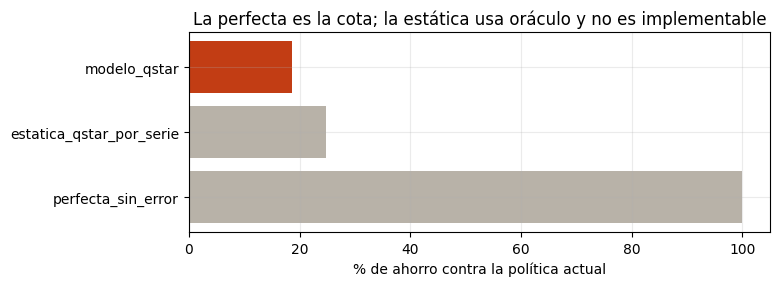

In [6]:
fig, eje = plt.subplots(figsize=(7.5, 2.6))
sub = tabla.set_index("policy")["saving_pct"].drop(pol.CURRENT_POLICY, errors="ignore")
colores = ["#C23D14" if i == pol.MODEL_POLICY else "#B8B2A8" for i in sub.index]
eje.barh(sub.index, sub.to_numpy(), color=colores)
eje.set_xlabel("% de ahorro contra la política actual")
eje.set_title("La perfecta es la cota; la estática usa oráculo y no es implementable")
plt.show()

> **Alcance de este número.** Es una corrida reducida: 400 series y 3 orígenes, contra las 3.066
> series y 8 orígenes del reporte oficial. La política estática se beneficia más cuando hay pocos
> orígenes, porque su cuantil de oráculo se estima sobre menos días de test y le queda más
> ajustado. El número que vale es el de `make models`; este sirve para ver el mecanismo.

Que esta comparación esté en el notebook y pueda salir negativa es deliberado. Un proyecto que
solo reporta «el modelo ahorra 18,5 %» se atribuye también el mérito de haber elegido bien el
cuantil, y esa es la parte que no requiere machine learning.

## 2 · Nivel de servicio, en sus dos definiciones

Confundirlas es común y dan números distintos:

- **`fill_rate`**: fracción de la demanda satisfecha. Ponderado por **unidades**.
- **`cycle_service_level`**: fracción de **días** sin quiebre.

Un producto con un solo día malo y muy malo puede tener buen nivel de servicio por ciclo y mal
fill rate. Se reportan los dos.

In [7]:
display(
    tabla.set_index("policy")[
        ["fill_rate", "cycle_service_level", "spoilage_rate", "mean_order"]
    ].round(4)
)
print("`spoilage_rate` es la fracción de lo pedido que no se vendió. En perecederos")
print("es merma real, no capital inmovilizado, y es el término que Co representa.")

,fill_rate,cycle_service_level,spoilage_rate,mean_order
policy,,,,
perfecta_sin_error,1.0000,1.0000,0.0000,1.4372
estatica_qstar_por_serie,0.8674,0.6558,0.1878,1.5349
modelo_qstar,0.8546,0.6107,0.2000,1.5353
actual_promedio_movil,0.7518,0.4781,0.1627,1.2905


`spoilage_rate` es la fracción de lo pedido que no se vendió. En perecederos
es merma real, no capital inmovilizado, y es el término que Co representa.


## 3 · Sensibilidad a la economía

El cociente $C_o/C_u$ es el **único** parámetro que importa: $q^*$ depende solo de él. Así que se
barre ese y no las dos magnitudes por separado.

Un rango con supuestos visibles convence más que un número único sin origen.

In [8]:
del_modelo = resultado[resultado[C.MODEL] == modelo_lgbm]
sens = nv.sensitivity_to_economics(
    del_modelo[C.Y_TRUE],
    del_modelo,
    quantiles=cuantiles,
    co_over_cu=(0.3, 0.6, 1.0, 1.5),
)
display(
    sens[
        ["co_over_cu", "critical_fraction", "mean_order", "fill_rate", "spoilage_rate", "mean_cost"]
    ].round(4)
)

,co_over_cu,critical_fraction,mean_order,fill_rate,spoilage_rate,mean_cost
0,0.3,0.7692,1.7545,0.9040,0.2595,0.2746
1,0.6,0.6250,1.5353,0.8546,0.2000,0.3932
2,1.0,0.5000,1.3839,0.8074,0.1616,0.5004
3,1.5,0.4000,1.2071,0.7388,0.1204,0.5934


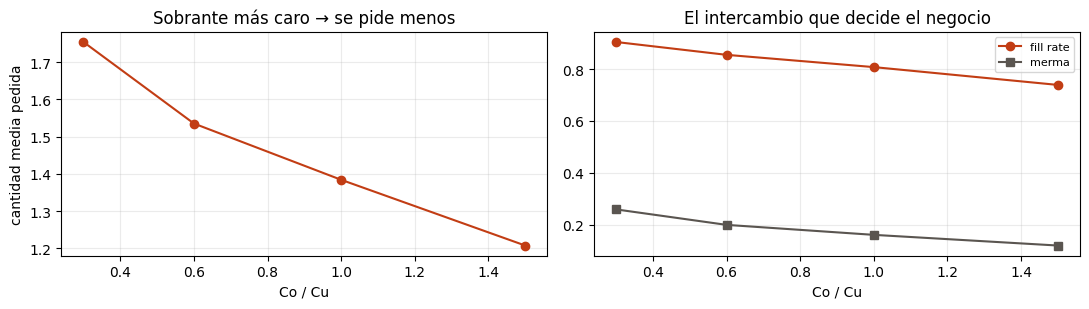

Este gráfico es el argumento de por qué la interfaz expone el ratio como
control y no como constante: mueve la decisión, y no es del modelo elegirlo.


In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.2))
ejes[0].plot(sens["co_over_cu"], sens["mean_order"], marker="o", color="#C23D14")
ejes[0].set_xlabel("Co / Cu")
ejes[0].set_ylabel("cantidad media pedida")
ejes[0].set_title("Sobrante más caro → se pide menos")

ejes[1].plot(sens["co_over_cu"], sens["fill_rate"], marker="o", label="fill rate", color="#C23D14")
ejes[1].plot(
    sens["co_over_cu"], sens["spoilage_rate"], marker="s", label="merma", color="#5A5550"
)
ejes[1].set_xlabel("Co / Cu")
ejes[1].set_title("El intercambio que decide el negocio")
ejes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print("Este gráfico es el argumento de por qué la interfaz expone el ratio como")
print("control y no como constante: mueve la decisión, y no es del modelo elegirlo.")

## 4 · Capa 2 · La traducción a moneda, paramétrica

Acá es donde hay que declarar supuestos. `roi_monetary` **no** toma nada del dataset: recibe un
perfil de operación explícito y devuelve un rango.

No se atribuye a ninguna empresa concreta, y los cuatro supuestos van a la vista.

In [10]:
import inspect

print(inspect.signature(pol.roi_monetary))
print()
print(inspect.getdoc(pol.roi_monetary))

(relative: 'dict[str, float]', *, annual_revenue: 'float', gross_margin: 'float', base_spoilage_rate: 'float', capture_fraction: 'float') -> 'dict[str, float]'

Capa 2 de docs/roi.md: traduccion **parametrica** a moneda.

Los cuatro argumentos son supuestos **declarados, no observados**, y estan asi
en la firma para que no haya forma de calcular esto sin nombrarlos. No se
atribuyen a ninguna empresa concreta: el dataset primario esta normalizado, y
los guaranies del caso Focal Point salen del generador sintetico.

`capture_fraction` es el supuesto mas fragil y el que domina la sensibilidad.
Nunca es 1,0: entre la mejora del pronostico y la mejora realizada hay
ejecucion, restricciones de proveedor y decisiones humanas.


**Por qué este notebook no imprime una cifra en guaraníes.** Porque haría falta fijar los cuatro
supuestos del perfil de operación, y hacerlo acá los volvería invisibles: quedarían en una celda
y se leerían como un resultado. Van en `docs/roi.md`, declarados, y la función existe para que la
conversión sea reproducible cuando alguien aporte su perfil real.

La regla es la misma que gobierna el resto del proyecto: un número cuyo origen no se puede
auditar es peor que no tener número.

## 5 · Lo que esta corrida no prueba

Conviene tenerlo escrito antes de que lo pregunten.

**El newsvendor es de un solo período.** Para perecederos con vida útil mayor al período de
revisión, el modelo correcto es de inventario perecedero multi-período con despacho por
antigüedad. La aproximación vale cuando la vida útil se parece al período de revisión, que es el
caso de fresco diario.

**No se modela lead time ni multi-echelon.** Se asume que lo pedido llega para el período
siguiente.

**No se modelan restricciones operativas de la orden**: cantidad mínima, múltiplos de caja o
pallet, capacidad de cámara. La salida es un número continuo.

**La política actual simulada es optimista contra sí misma.** Pide el pronóstico puntual sin
margen, y una operación real suele agregar un colchón heurístico. Eso haría que la política
actual gaste más en merma y menos en faltante — el ahorro medido acá es de la forma «decidir con
la economía contra decidir con el promedio», no «contra la mejor planilla posible».

## Lo que sale de acá

- El ROI va **en porcentaje** porque el dataset está normalizado por un coeficiente no
  divulgado. Es la única cifra que los datos soportan.
- El costo esperado se mide **contando** sobre las ventanas del backtest, no con fórmula cerrada.
- Se compara contra **cuatro** políticas, y la estática es la que hace interpretable el ahorro:
  separa el aporte del pronóstico del aporte de la economía. En esta corrida reducida la
  estática **le gana al modelo**, y eso es información, no un error de medición: acota cuánto se
  puede atribuir al pronóstico diario.
- El nivel de servicio se reporta en sus dos definiciones, porque dan números distintos.
- La sensibilidad a $C_o/C_u$ es el argumento de por qué ese ratio es un control de la interfaz
  y no una constante del modelo.
- La traducción a moneda existe, es paramétrica, y sus supuestos viven en `docs/roi.md` y no en
  una celda.

---

**Fin de la serie.** El recorrido completo: `01` los datos y la censura · `02` las features y la
prueba de que no miran el futuro · `03` el backtest de origen móvil · `04` la estructura del
catálogo · `05` del pronóstico a la cantidad · `06` el impacto económico.